<a href="https://colab.research.google.com/github/klholmes1728-a11y/ores5160-2026/blob/main/week09_assignment_KHolmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Q1.1
import csv

with open("est2018-pop-res.csv", newline='') as file:
    reader = csv.reader(file)

    for i, row in enumerate(reader):
        print(row)
        if i == 4:
            break

['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']


In [2]:
#Q1.2
import pandas as pd

df = pd.read_csv("est2018-pop-res.csv")

df.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
0,10,0,0,0,United States,327167434,253768092,77.6
1,40,3,6,1,Alabama,4887871,3798031,77.7
2,40,4,9,2,Alaska,737438,553622,75.1
3,40,4,8,4,Arizona,7171646,5528989,77.1
4,40,3,7,5,Arkansas,3013825,2310645,76.7


In [3]:
df.shape

(53, 8)

In [4]:
df.columns

Index(['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018',
       'POPEST18PLUS2018', 'PCNT_POPEST18PLUS'],
      dtype='object')

In [5]:
#Q1.3
#'POPESTIMATE2018' is most likely the total population column
df.sort_values(by="POPESTIMATE2018", ascending=False)[["NAME", "POPESTIMATE2018"]].head()

,NAME,POPESTIMATE2018
0,United States,327167434
5,California,39557045
44,Texas,28701845
10,Florida,21299325
33,New York,19542209


In [6]:
#Q2.1
states = df[df["SUMLEV"] == 40]

states["POPESTIMATE2018"].mean()

np.float64(6353126.673076923)

In [10]:
#Q2.2
df["SUMLEV"].unique()

array([10, 40])

In [11]:
states = df[df["SUMLEV"] == 40]

region_pop = states.groupby("REGION")["POPESTIMATE2018"].sum()

region_pop

,POPESTIMATE2018
REGION,
1,56111079
2,68308744
3,124753948
4,77993663
X,3195153


In [12]:
region_pop.idxmax()
#Region 3 has the highest popluation

'3'

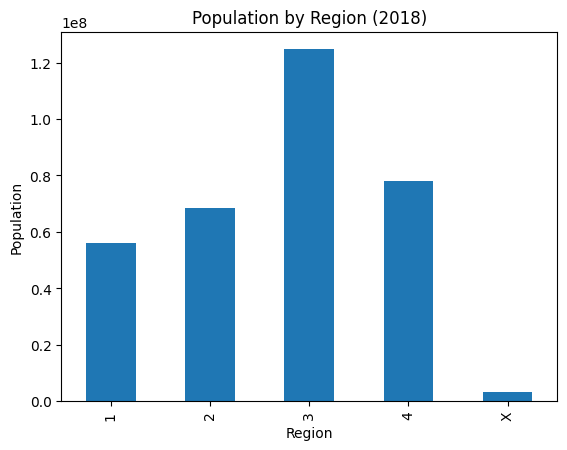

In [13]:
#Q2.3 Barchart of population by region
import matplotlib.pyplot as plt

region_pop.plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Population")
plt.title("Population by Region (2018)")
plt.show()

In [15]:
#Q3.1
import json

with open("patient.json") as f:
    patient = json.load(f)

print(type(patient))

<class 'dict'>


In [18]:
#Q3.2
name = patient["name"][0]
full_name = " ".join(name["given"]) + " " + name["family"]

print("Full Name:", full_name)

print("Gender:", patient["gender"])
print("Birth Date:", patient["birthDate"])

address = patient["address"][0]

print("City:", address["city"])
print("State:", address["state"])
print("Postal Code:", address["postalCode"])

Full Name: Peter James Chalmers
Gender: male
Birth Date: 1974-12-25
City: PleasantVille
State: Vic
Postal Code: 3999


In [19]:
#Q3.3 Count phone numbers
phones = patient["telecom"]

print("Number of phone numbers:", len(phones))

Number of phone numbers: 4


In [22]:
phones = patient["telecom"]

print("Number of telecom entries:", len(phones))

print("Types:")
for p in phones:
    print("-", p.get("system"), "(", p.get("use"), ")")

Number of telecom entries: 4
Types:
- None ( home )
- phone ( work )
- phone ( mobile )
- phone ( old )
